In [ ]:
!py -m pip install lightgbm -q

In [6]:
import pandas as pd

df = pd.read_csv("data/macro/combined_macro_data.csv", parse_dates=["date"])

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance

### pipeline 

In [15]:
def rf_cpiret_prediction(data, use_macro, model,
                         use_scaling, scaler_type,
                         test_quarters=4):

    macro_vars = [
    "YLDMAT", "DAYMAT", "wti_price",
    "trade_balance", "eci", "gdp", "gscpi", "long_term_rate",
    "median_cpi", "nfci", "anfci", "nfci_risk", "nfci_credit",
    "nfci_leverage", "nfci_nonfinancial_leverage", "ppi",
    "real_property_price", "unrate"
    ]

    df = data.copy()
    df = df.sort_values("date")
    dates = df["date"]

    X = df.drop(columns=["cpiret", "date"])
    y = df["cpiret"]

    if not use_macro:
        X = X.drop(columns=macro_vars, errors="ignore")

    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    steps = []
    if use_scaling:
        scalers = {
            'standard': StandardScaler(),
            'robust':   RobustScaler(),
            'minmax':   MinMaxScaler()
        }
        steps.append(('scaler', scalers.get(scaler_type, StandardScaler())))

    if model == 'RF':
        regressor = RandomForestRegressor(n_estimators=500, random_state=42)
    elif model == 'GB':
        regressor = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
        )
    elif model == 'XGB':
        regressor = XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, objective='reg:squarederror'
        )
    elif model == 'KNN':
        regressor = KNeighborsRegressor(n_neighbors=5, weights='distance')
    elif model == 'SVR':
        regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    elif model == 'bayes':
        regressor = BayesianRidge()
    elif model == 'catboost':
        regressor = CatBoostRegressor(
            iterations=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=3.0, random_state=42, verbose=0
        )

    steps.append(('model', regressor))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']


    mse = mean_squared_error(y_test, predictions)
    r2  = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })
    print(f"\n{'='*55}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*55}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{row['date'].strftime('%Y-%m-%d'):<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*55}")
    print(f"{'MSE:':>40} {mse:>12.6f}")
    print(f"{'R²:':>40} {r2:>12.4f}")
    print(f"{'='*55}")

    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=20, random_state=42)
        importances = perm.importances_mean

    fi_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Split into macro vs other
    macro_fi = fi_df[fi_df['feature'].isin(macro_vars)].reset_index(drop=True)
    other_fi = fi_df[~fi_df['feature'].isin(macro_vars)].reset_index(drop=True)

    n_plots = 2 + (1 if use_macro and not macro_fi.empty else 0) + (1 if not other_fi.empty else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.array(axes).flatten()

    ax_idx = 0

    x = range(len(results))
    axes[ax_idx].plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    axes[ax_idx].plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(results["date"].dt.strftime('%Y-%m-%d'), rotation=45)
    axes[ax_idx].set_xlabel("Quarter")
    axes[ax_idx].set_ylabel("cpiret")
    axes[ax_idx].set_title(f"CPI Prediction — {model}\n(R²={r2:.3f}  MSE={mse:.6f})")
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)
    ax_idx += 1

    # Macro importance
    if use_macro and not macro_fi.empty:
        axes[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        axes[ax_idx].set_title(f"Macro Variable Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    #  Other features importance 
    if not other_fi.empty:
        axes[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        axes[ax_idx].set_title(f"Other Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)

    macro_label = "With Macro" if use_macro else "Without Macro"
    plt.suptitle(f"{model} | {macro_label} | Scaler: {scaler_type}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results, mse, r2

### XGB


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31          0.018211     0.006020     0.012191
2024-06-30          0.005901     0.005012     0.000889
2024-09-30          0.003584     0.010462     0.006878
2024-12-31          0.000964     0.008407     0.007443
-------------------------------------------------------
                                    MSE:     0.000063
                                     R²:      -0.4416


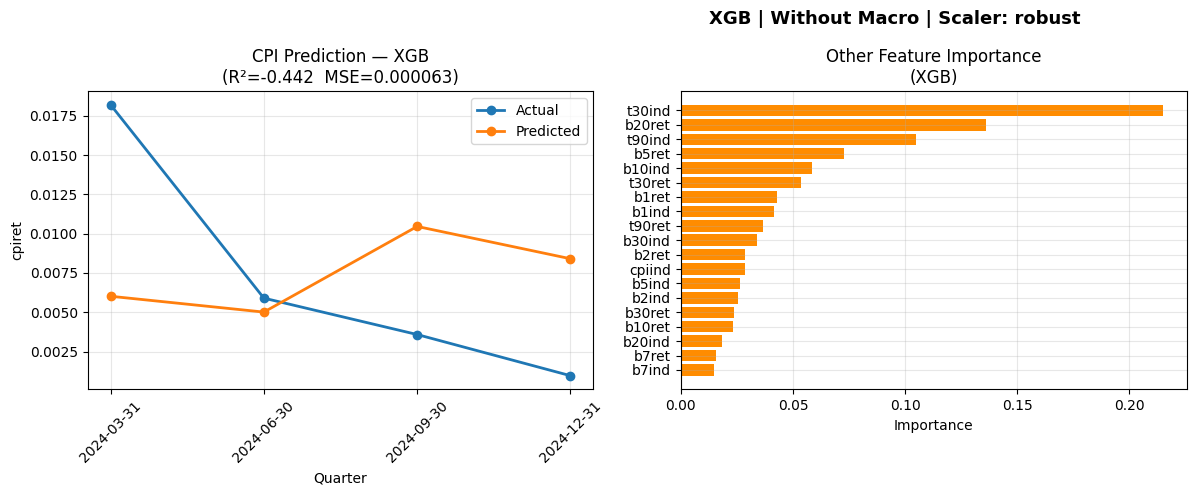

In [16]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=False,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31          0.018211     0.011592     0.006619
2024-06-30          0.005901     0.011035     0.005134
2024-09-30          0.003584     0.003468     0.000116
2024-12-31          0.000964     0.004318     0.003354
-------------------------------------------------------
                                    MSE:     0.000020
                                     R²:       0.5344


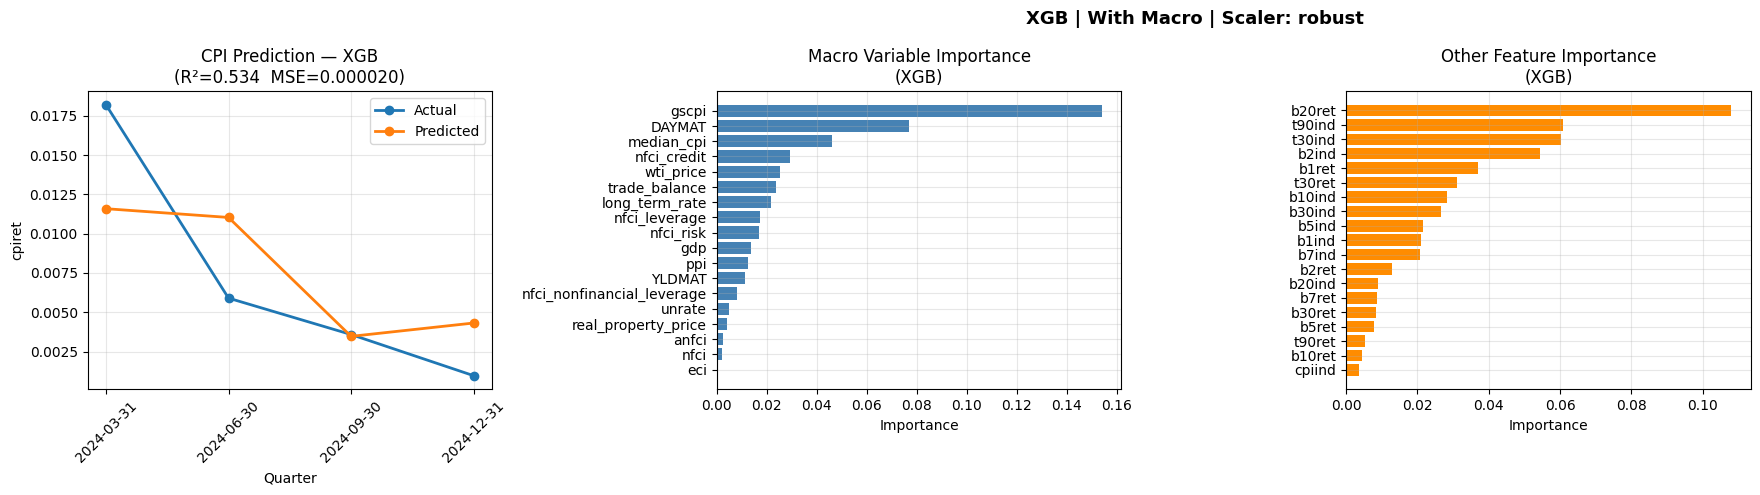

In [17]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### Catboost


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-28          0.018211     0.004695     0.013516
2024-06-28          0.005901     0.003710     0.002191
2024-09-30          0.003584     0.009869     0.006285
2024-12-31          0.000964     0.010149     0.009185
-------------------------------------------------------
                                    MSE:     0.000078
                                     R²:      -0.7803


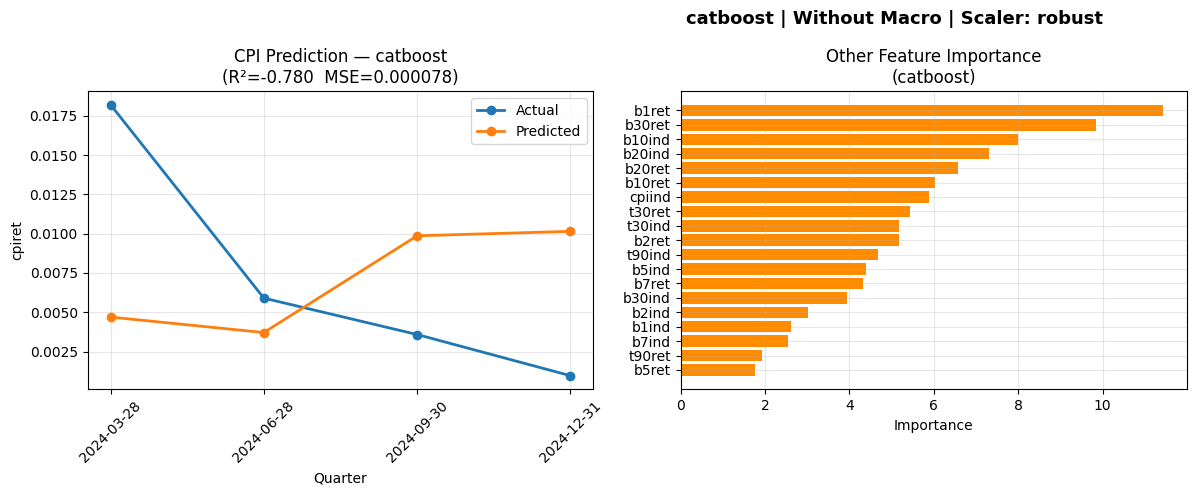

In [10]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=False,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-28          0.018211     0.012593     0.005618
2024-06-28          0.005901     0.011425     0.005524
2024-09-30          0.003584     0.004290     0.000706
2024-12-31          0.000964     0.002577     0.001613
-------------------------------------------------------
                                    MSE:     0.000016
                                     R²:       0.6273


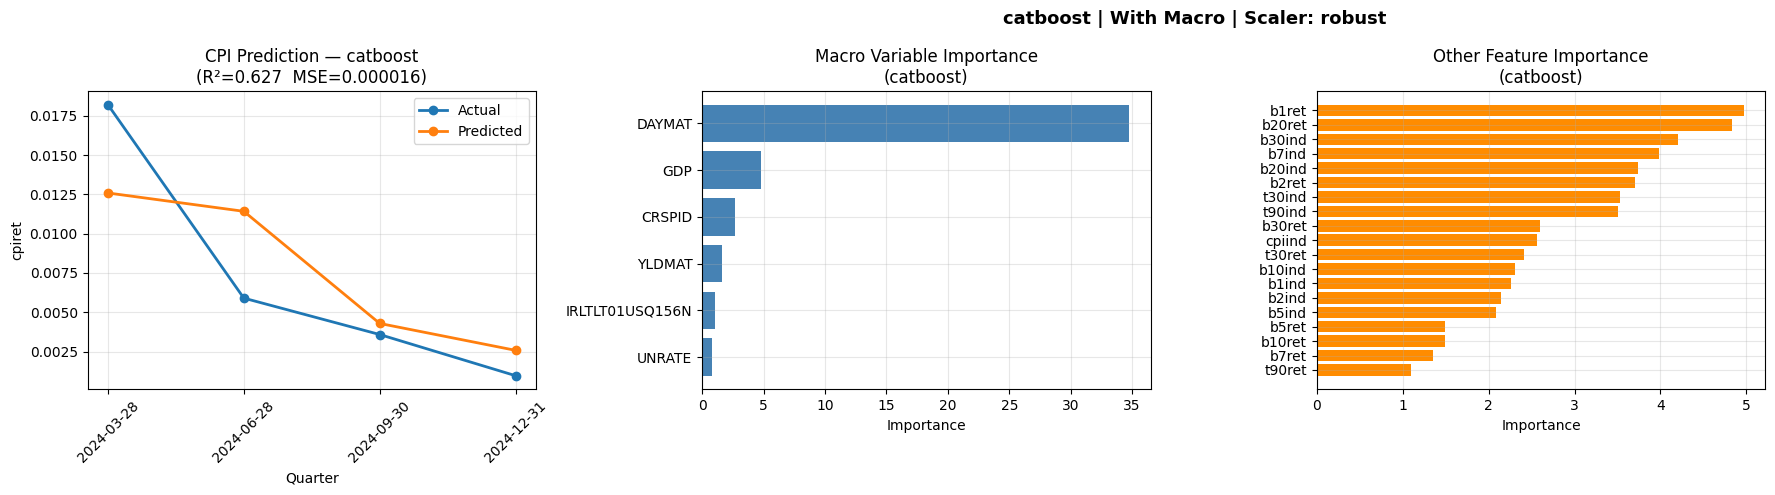

In [59]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### bayes


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-28          0.018211     0.010642     0.007569
2024-06-28          0.005901     0.010073     0.004172
2024-09-30          0.003584     0.006890     0.003306
2024-12-31          0.000964     0.014501     0.013537
-------------------------------------------------------
                                    MSE:     0.000067
                                     R²:      -0.5374


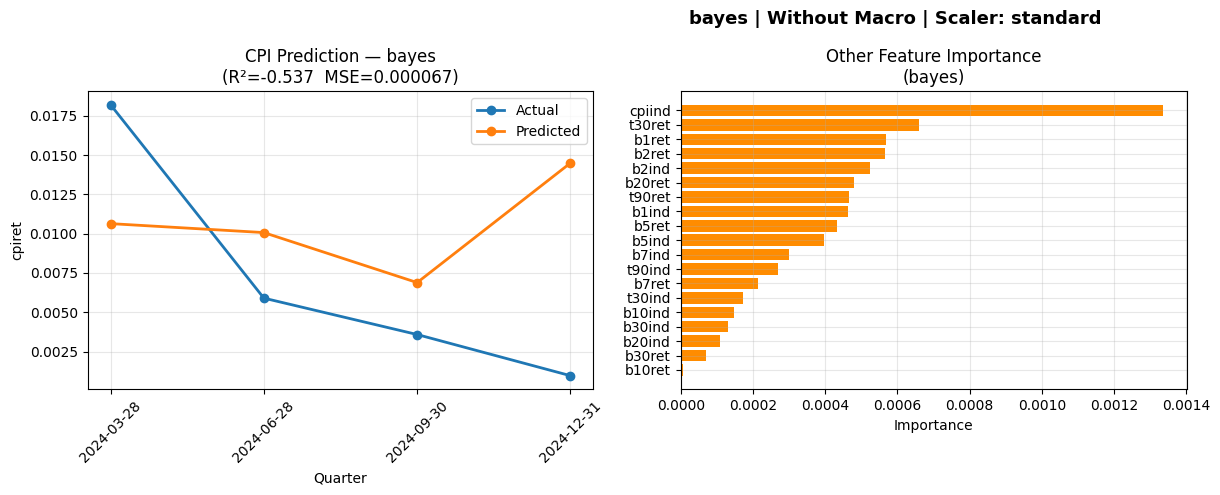

In [11]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=False,
    model='bayes',
    use_scaling=True,
    scaler_type='standard',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-28          0.018211     0.017057     0.001154
2024-06-28          0.005901     0.010823     0.004922
2024-09-30          0.003584     0.007309     0.003725
2024-12-31          0.000964     0.005123     0.004159
-------------------------------------------------------
                                    MSE:     0.000014
                                     R²:       0.6756


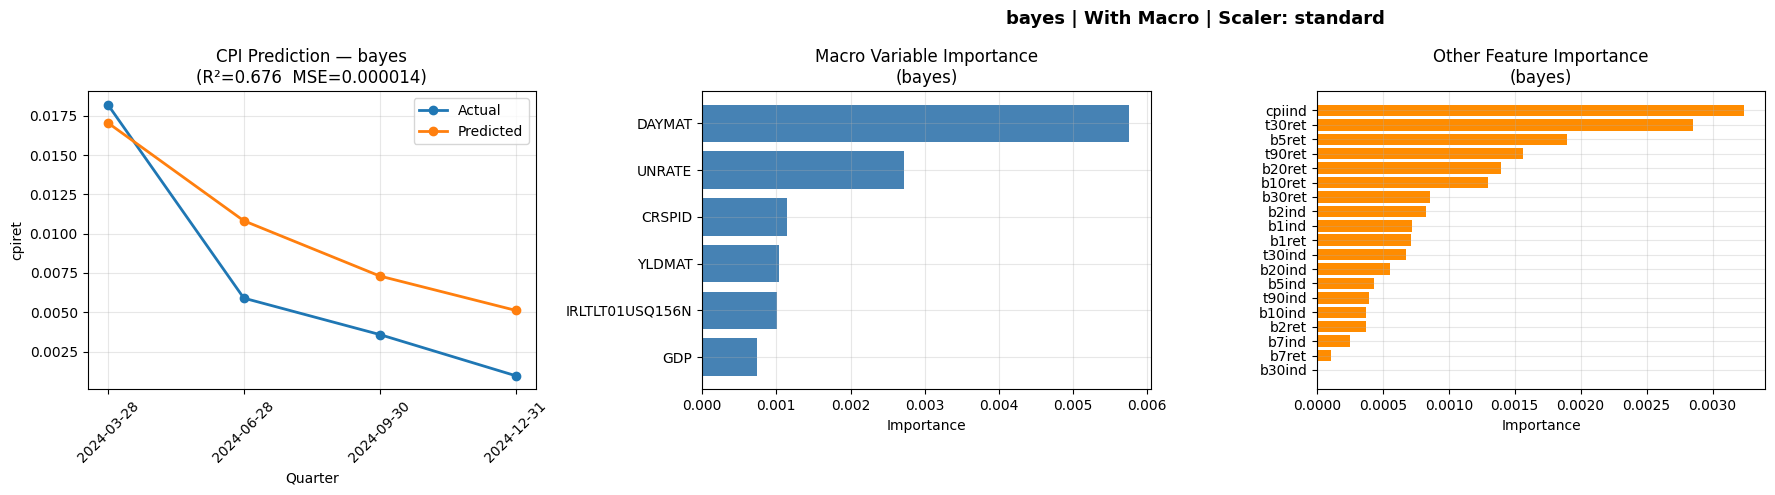

In [ ]:

# Usage
results, mse, r2 = rf_cpiret_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    scaler_type='standard',
    test_quarters=4
)